In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read all the words

words=open('names.txt','r').read().splitlines()

In [3]:
words[:3]

['emma', 'olivia', 'ava']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)


In [8]:
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [9]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [203]:
X

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        ...,
        [15, 22,  1],
        [22,  1, 14],
        [ 1, 14,  9]])

In [204]:
## let's build embedding neural network

In [10]:
C = torch.randn((27, 2))


In [206]:
C[5]

tensor([-1.8927,  0.9012])

In [15]:
C[X].shape

torch.Size([228146, 3, 2])

In [14]:
emb=C[X]
emb.shape


torch.Size([228146, 3, 2])

In [16]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [17]:
W1,b1

(tensor([[-1.2392, -1.0304, -0.9630, -1.3288, -0.3263, -0.2924, -0.3169, -1.9561,
           0.5491,  1.5113, -1.1305, -1.2901, -0.7304, -0.4927,  0.7275,  0.0040,
          -0.4831,  1.1048,  1.0849,  0.7344,  1.1929, -1.2668,  0.3030, -0.9672,
           2.4938,  0.2353, -0.9595, -0.3684,  0.5809,  1.2870,  1.0777, -1.1300,
           1.1559, -0.2329, -1.3317, -0.3877,  0.7785, -0.6170, -1.0221,  1.0539,
          -0.0860,  0.1238,  0.5255,  0.2770, -1.1569, -1.6672, -0.5036,  0.1940,
           0.5594,  0.1768,  0.7333,  0.4287, -0.1940,  2.0069,  0.1807, -0.6353,
           0.5350, -1.3464, -1.4929,  1.3213, -0.9180,  1.1060,  1.9419,  1.8652,
           1.0388, -1.2619, -0.3303,  1.9178,  0.0660, -0.3355, -1.2079, -0.0836,
           2.3562, -0.6024, -0.7450,  0.4045, -0.0423,  1.6165,  0.6815,  1.8589,
           0.4359,  0.0097, -0.4874, -1.0019, -0.6287, -0.0723, -1.7507,  1.3550,
          -1.3771,  2.3063, -0.1405,  1.0140,  0.3421,  0.7548, -0.9516,  0.9307,
          -0.394

In [211]:
# torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([228146, 6])

In [212]:
# torch.cat(torch.unbind(emb,1),1).shape

torch.Size([228146, 6])

In [213]:
# a=torch.arange(18)

In [20]:
# a.view(9,2)

In [19]:
# a.storage()

In [21]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [22]:
h.shape

torch.Size([228146, 100])

In [23]:
W2=torch.randn(100,27)
b2=torch.randn(27)

In [24]:
W2,b2

(tensor([[ 0.5006,  0.0485,  0.1977,  ..., -0.1393,  1.1869, -0.0618],
         [-0.1592, -0.3934,  1.1659,  ..., -1.0668, -1.6018,  0.9442],
         [-1.1159, -1.6011,  0.6128,  ...,  1.0711, -0.9639, -0.3594],
         ...,
         [ 0.8222,  1.9578, -0.1610,  ...,  0.5445,  1.5284, -0.4388],
         [-1.4044, -1.3217,  0.2252,  ...,  1.6366,  1.1331,  1.6656],
         [-0.5228,  0.4726, -0.7402,  ...,  0.2249,  0.1743, -0.7590]]),
 tensor([-0.0594, -0.9781, -0.1835,  0.2176, -0.7216,  0.9456, -0.8030,  0.8112,
         -0.9967,  0.8417, -0.1387,  0.8952,  1.1104, -0.0395,  1.3125,  0.8916,
          0.1519, -0.1433, -0.6907,  0.8702,  0.6684,  0.0649, -1.5378, -0.0462,
         -0.7365, -0.9285,  1.6920]))

In [25]:
logits=h @ W2 +b2 

In [26]:
logits.shape

torch.Size([228146, 27])

In [27]:
counts=logits.exp()

In [28]:
prob=counts/counts.sum(1,keepdims=True)

In [29]:
prob.shape

torch.Size([228146, 27])

In [33]:
loss = F.cross_entropy(logits, Y)

In [73]:

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [74]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [75]:
Xtr.shape, Ytr.shape # dataset


(torch.Size([182580, 3]), torch.Size([182580]))

In [76]:
for p in parameters:
  p.requires_grad = True

In [77]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [78]:
lri = []
lossi = []
stepi = []


In [79]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  # print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())
    
print(loss.item())

1.7251181602478027


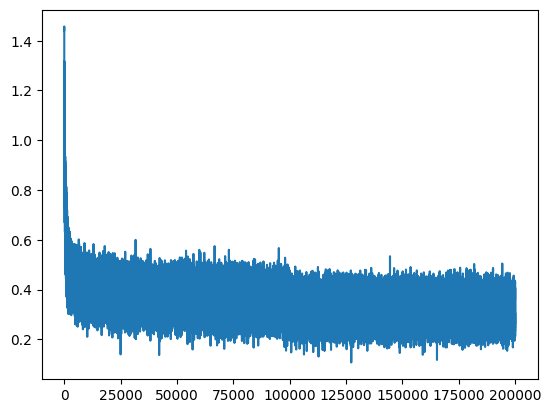

In [80]:
plt.plot(stepi,lossi)

In [83]:

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss


tensor(2.1404, grad_fn=<NllLossBackward0>)

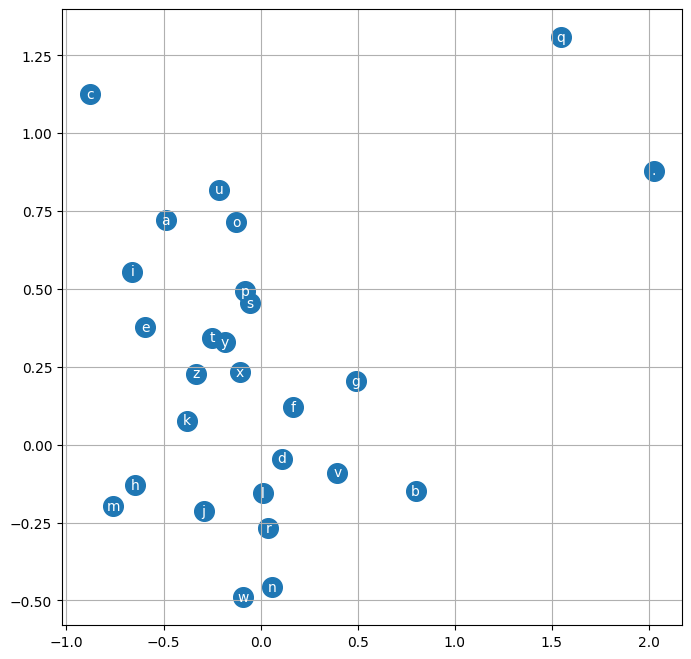

In [84]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')


In [53]:
# training split,dev or validation split,test split
# 80% ,10% ,10% 

In [85]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [87]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmah.
amille.
khi.
mili.
taty.
skanden.
jazhet.
faverystingeli.
nellara.
chaiim.
kaleigh.
ham.
join.
quint.
shon.
marian.
quin.
elo.
dearyni.
jaxen.
